# Facteurs qui influencent les performances commerciales

**Auteur :** BOUKAR Sadjo Doubla
**Objectif :** identifier les facteurs qui influencent le montant des commandes (`TotalPrice`) et comparer deux approches de modélisation (régression linéaire vs Random Forest) pour évaluer leur capacité prédictive.

**Données :** `sales_2.csv` — historique de commandes commerciales (quantité, prix unitaire, catégorie de produit, région, statut de la commande).

## Plan
1. Chargement et nettoyage des données
2. Sélection et encodage des variables
3. Analyse des corrélations
4. Modélisation : régression linéaire vs Random Forest
5. Importance des variables
6. Conclusion

## 1. Chargement et nettoyage des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("sales_2.csv")
df.columns = df.columns.str.strip()
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
df = df.dropna()

# On garde uniquement les commandes effectivement livrées : une commande annulée ou
# en attente ne reflète pas une "performance commerciale" réalisée.
df = df[df["OrderStatus"] == "Delivered"].copy()
print("Dimensions après nettoyage :", df.shape)
df.head()

Dimensions après nettoyage : (295, 13)


,OrderID,CustomerID,CompanyName,ProductID,ProductName,Category,RegionID,RegionName,OrderDate,Quantity,UnitPrice,TotalPrice,OrderStatus
0,ORD-0001,C005,AI Systems,P002,Smartphone,Electronics,R004,West,2023-05-18,1,1344,1344,Delivered
1,ORD-0001,C005,AI Systems,P004,Monitor,Electronics,R004,West,2023-05-18,1,390,390,Delivered
2,ORD-0001,C005,AI Systems,P005,Keyboard,Accessories,R004,West,2023-05-18,4,1140,4560,Delivered
7,ORD-0004,C007,NextGen Consulting,P008,Smartwatch,Electronics,R001,North,2023-10-05,3,1435,4305,Delivered
8,ORD-0004,C007,NextGen Consulting,P005,Keyboard,Accessories,R001,North,2023-10-05,2,668,1336,Delivered


## 2. Sélection et encodage des variables

**Variable cible :** `TotalPrice` (montant de la ligne de commande).

**Variables explicatives retenues :** `Quantity`, `Category`, `RegionName`.

> `UnitPrice` est volontairement exclu des variables explicatives : comme `TotalPrice = Quantity × UnitPrice`, l'inclure rendrait la prédiction quasi triviale (R² proche de 1) sans intérêt analytique. L'objectif ici est de comprendre l'effet de facteurs commerciaux (volume commandé, catégorie de produit, région) sur le montant généré, indépendamment du niveau de prix déjà fixé.

In [3]:
features = ["Quantity", "Category", "RegionName"]
target = "TotalPrice"
df_model = df[features + [target]].copy()

le_category = LabelEncoder()
le_region = LabelEncoder()
df_model["Category"] = le_category.fit_transform(df_model["Category"])
df_model["RegionName"] = le_region.fit_transform(df_model["RegionName"])

df_model.head()

,Quantity,Category,RegionName,TotalPrice
0,1,1,3,1344
1,1,1,3,390
2,4,0,3,4560
7,3,1,1,4305
8,2,0,1,1336


## 3. Analyse des corrélations

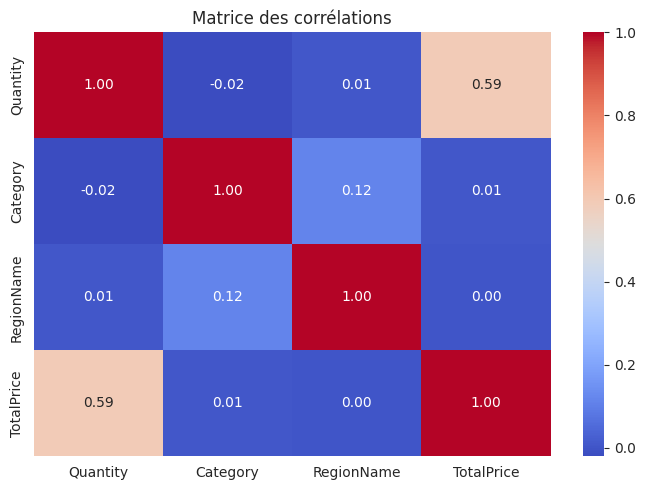

In [4]:
plt.figure(figsize=(7, 5))
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice des corrélations")
plt.tight_layout()
plt.show()

Sans surprise, `Quantity` est la variable la plus corrélée avec `TotalPrice`. La catégorie et la région présentent des corrélations plus faibles avec la cible.

## 4. Modélisation : régression linéaire vs Random Forest

On compare un modèle simple (régression linéaire) à un modèle non linéaire (Random Forest), entraînés sur 80% des données et évalués sur les 20% restants.

In [5]:
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"Régression linéaire -> R² : {r2_lr:.3f} | MAE : {mae_lr:.1f}")

Régression linéaire -> R² : 0.272 | MAE : 1152.9


In [7]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest -> R² : {r2_rf:.3f} | MAE : {mae_rf:.1f}")

Random Forest -> R² : 0.297 | MAE : 1138.3


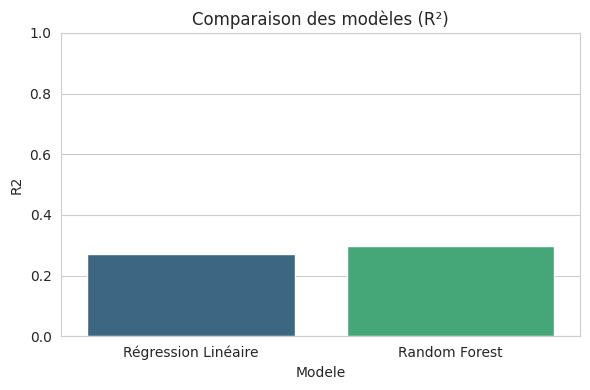

,Modele,R2,MAE
0,Régression Linéaire,0.271677,1152.858675
1,Random Forest,0.296958,1138.311895


In [8]:
comparison = pd.DataFrame({
    "Modele": ["Régression Linéaire", "Random Forest"],
    "R2": [r2_lr, r2_rf],
    "MAE": [mae_lr, mae_rf]
})

plt.figure(figsize=(6, 4))
sns.barplot(x="Modele", y="R2", hue="Modele", data=comparison, palette="viridis", legend=False)
plt.title("Comparaison des modèles (R²)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
comparison

Les deux modèles obtiennent un R² modeste (environ 0,27 à 0,30) : `Quantity`, `Category` et `RegionName` seuls n'expliquent qu'une partie limitée de la variation du montant des commandes. Le Random Forest fait légèrement mieux que la régression linéaire, ce qui suggère une relation pas totalement linéaire entre ces variables et la cible, mais l'écart reste faible.

## 5. Importance des variables

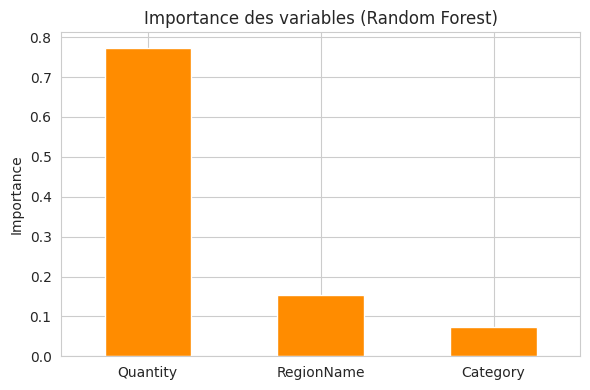

Quantity      0.773597
RegionName    0.152852
Category      0.073550
dtype: float64

In [9]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(6, 4))
importances.plot(kind="bar", color="darkorange")
plt.title("Importance des variables (Random Forest)")
plt.ylabel("Importance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
importances

## 6. Conclusion

- `Quantity` est, de loin, le facteur le plus déterminant du montant d'une commande — ce qui est logique commercialement.
- La région et la catégorie de produit ont une influence secondaire mais non négligeable.
- Le pouvoir explicatif global reste limité (R² ≈ 0,30) : d'autres facteurs non présents dans ce dataset (saisonnalité, promotions, profil du client, canal de vente) influencent probablement davantage le montant des commandes.

**Limites :** l'échantillon final (commandes livrées uniquement) est restreint (~295 lignes), ce qui limite la robustesse statistique des résultats. Une étude future pourrait inclure davantage de variables contextuelles et un historique plus large.